In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sunpy.visualization.colormaps as sunpycm
import torch
from omegaconf import OmegaConf

from sdofmv2.core import MAE, SDOMLDataModule, inverse_log_norm, mapping_dense_to_rgb
from sdofmv2.utils import ALL_WAVELENGTHS

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cfg = OmegaConf.load(
    "../../configs/pretrain/pretrain_mae_AIA.yaml"
    )

In [3]:
data_module = SDOMLDataModule(
    hmi_path=os.path.join(
        cfg.data.sdoml.base_directory, 
        cfg.data.sdoml.sub_directory.hmi
    ) if cfg.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg.data.sdoml.base_directory,
        cfg.data.sdoml.sub_directory.aia,
    ) if cfg.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg.data.sdoml.components,
    wavelengths=cfg.data.sdoml.wavelengths,
    ions=cfg.data.sdoml.ions,
    frequency=cfg.data.sdoml.frequency,
    batch_size=cfg.model.misc.batch_size,
    num_workers=cfg.data.num_workers,
    val_months=cfg.data.month_splits.val,
    test_months=cfg.data.month_splits.test,
    holdout_months=cfg.data.month_splits.holdout,
    cache_dir=os.path.join(
        "../../assets",
        cfg.data.sdoml.sub_directory.cache,
    ),
    min_date=cfg.data.min_date,
    max_date=cfg.data.max_date,
    num_frames=cfg.model.mae.num_frames,
    drop_frame_dim=cfg.data.drop_frame_dim,
    apply_mask=cfg.data.sdoml.apply_mask,
    precision=cfg.experiment.precision,
    normalization=cfg.data.sdoml.normalization,
)
data_module.setup()

[* CACHE SYSTEM *] Found cached index data in ../../assets/cache/aligndata_AIA_FULL_12min_2010-05-0100:00:00-2018-12-3123:59:59.csv.


2026-03-09 01:47:33.320 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/131A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 01:47:33.322 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/1600A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 01:47:33.322 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/1700A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 01:47:33.323 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/171A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 01:47:33.323 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/193A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 01:47:33.324 | INFO     | sdofmv2.core.datamodu

[* CACHE SYSTEM *] Found cached HMI mask data in ../../assets/cache/hmi_mask_512x512.npy.


In [4]:
ckpt_dir = "../../assets/check_point/backbone/"
model = MAE.load_from_checkpoint(
    checkpoint_path= ckpt_dir + "AIA/id_6lfzuk01_mae_epoch=76-val_loss=0.00.ckpt", 
    map_location="cpu",
    weights_only=False)
model.eval()

MAE(
  (autoencoder): MaskedAutoencoderViT3D(
    (patch_embed): PatchEmbed(
      (proj): Conv3d(9, 768, kernel_size=(1, 16, 16), stride=(1, 16, 16))
      (norm): Identity()
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
          (drop1): Dropout(p=0.0, inplace=False)
       

In [5]:
timestamps = [
    "2011-12-25 00:12:00",
    "2012-12-25 00:12:00",
    "2013-12-25 00:12:00",
    "2014-12-25 00:12:00",
    "2015-12-25 00:12:00"
    ]

img_indices = [
    data_module.test_ds.aligndata.index.get_loc(
        pd.to_datetime(i_time)
    ) for i_time in timestamps
]

x_set = torch.cat([data_module.test_ds[i][0].unsqueeze(0) for i in img_indices], dim=0)
ts = [pd.to_datetime(data_module.test_ds[i][1]) for i in img_indices]

print(f"Datetime: {ts}")

Datetime: [Timestamp('2011-12-25 00:12:00'), Timestamp('2012-12-25 00:12:00'), Timestamp('2013-12-25 00:12:00'), Timestamp('2014-12-25 00:12:00'), Timestamp('2015-12-25 00:12:00')]


In [6]:
wavelenghs = ALL_WAVELENGTHS
wavelenghs.sort()

wave_val_list = []
for wave in wavelenghs:
    val = wave[:-1]
    wave_val_list.append(int(val))

wave_arr = np.array(wave_val_list)
sort_ids = np.argsort(wave_arr)

cms = [
    sunpycm.cmlist.get("sdoaia131"),
    sunpycm.cmlist.get("sdoaia1600"),
    sunpycm.cmlist.get("sdoaia1700"),
    sunpycm.cmlist.get("sdoaia171"),
    sunpycm.cmlist.get("sdoaia193"),
    sunpycm.cmlist.get("sdoaia211"),
    sunpycm.cmlist.get("sdoaia304"),
    sunpycm.cmlist.get("sdoaia335"),
    sunpycm.cmlist.get("sdoaia94"),
]

In [9]:
x_set_norm = x_set.clone()

# norm information
norm_stat = {"AIA": {}}
for ch_id, ch in enumerate(wavelenghs):
    
    cache_path = "../../assets/cache/AIA/"
    file_name = (
        ch
        + "_"
        + "_".join(data_module.cache_id.split("_")[-1:])
        + f"_norm-{data_module.normalization.type}"
        + ".json"
    )

    with open(cache_path + file_name, "r") as json_file:
        ch_stat = json.load(json_file)
    
    norm_stat["AIA"][ch] = ch_stat


# input/output inverse log transform for visualization
for img_id in range(x_set.shape[0]):
    for ch_id, ch in enumerate(wavelenghs):

        x_set_norm[img_id, ch_id, 0, :, :] = inverse_log_norm(
            x_set[img_id, ch_id, 0, :, :],
            norm_stat,
            "AIA",
            ch,
            cfg.data.sdoml.normalization.scaler_factor,
            cfg.data.sdoml.normalization.scaler_div_factor
        )

In [10]:
pca_results = []

for img_id in range(x_set.shape[0]):
    with torch.no_grad():
        latent, mask, ids_restore = model.autoencoder.forward_encoder(x_set_norm[[img_id]], mask_ratio=0)
    latent_size = latent.shape[1] - 1
    ids_keep = torch.argsort(ids_restore.squeeze())[:latent_size]
    feature_maps = latent[0, 1:, :]

    rgb_img = mapping_dense_to_rgb(
        feature_map=feature_maps, 
        visible_patch_ids=ids_keep,
        n_components=3,
        img_size=cfg.model.mae.img_size,
        grid_size=(cfg.model.mae.img_size // cfg.model.mae.patch_size),
        patch_size=cfg.model.mae.patch_size,
        pretrained=None
    )
    pca_results.append(rgb_img)

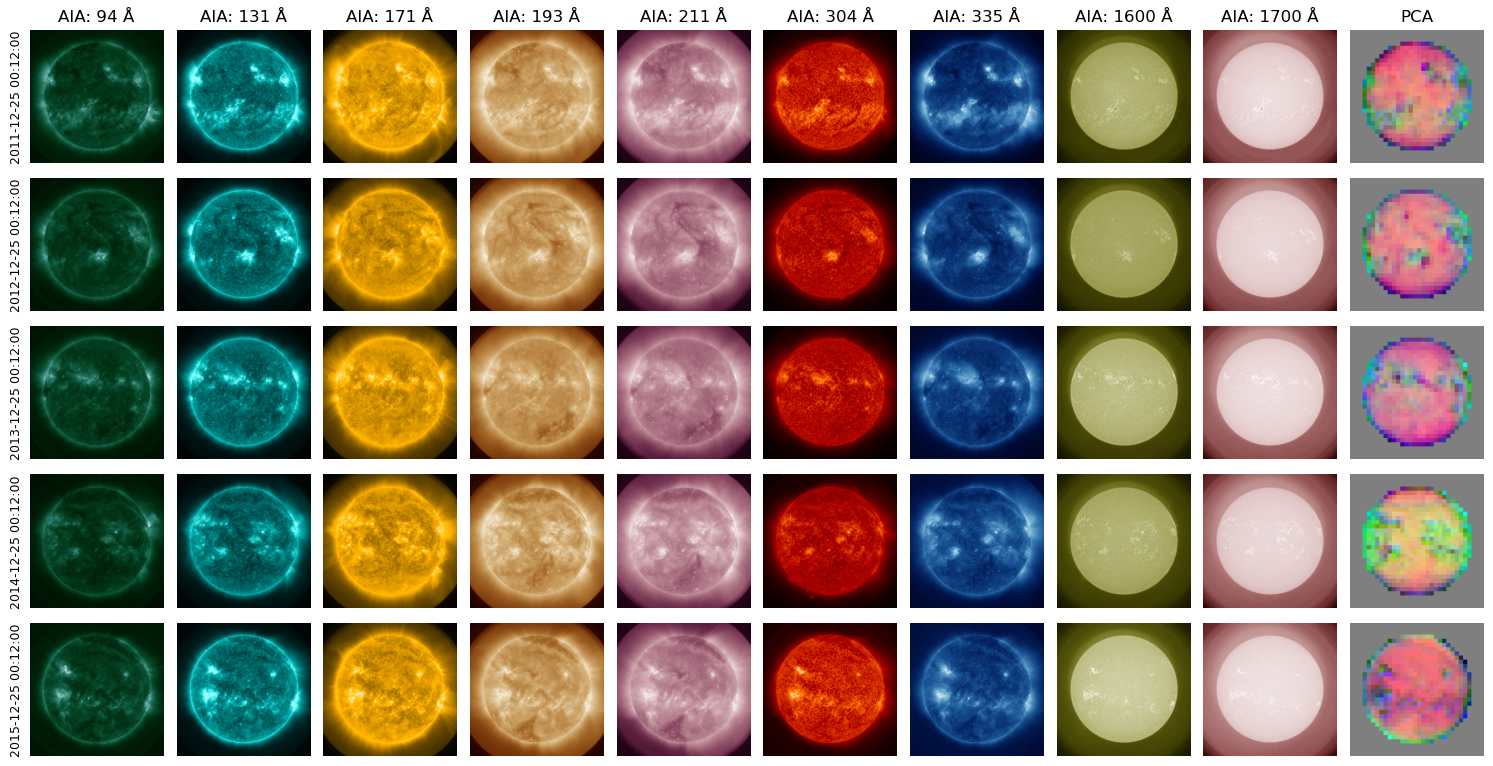

In [ ]:
num_images = x_set.shape[0]
fig, axes = plt.subplots(num_images, 10, figsize=(15, 8), squeeze=False)

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

ch_info = ["131", "1600", "1700", "171", "193", "211", "304", "335", "94"]

for i in range(num_images):
    for i_col, col in enumerate(sort_ids):
        if i == 0:
            axes[i, i_col].set_title(f"AIA: {ch_info[col]} Å", fontsize=12)
            axes[i, 9].set_title(f"PCA", fontsize=12)

        axes[i, i_col].imshow(x_set[i, col, 0, :, :].to("cpu").numpy(), cmap=cms[col])
        axes[i, i_col].axis('off')

    axes[i, 9].imshow(pca_results[i], cmap="binary")
    axes[i, 9].axis('off')

for row_idx in range(num_images):
    axes[row_idx][0].text(
        -0.1, 0.5,              # Negative x moves it to the left
        f"{ts[row_idx]}", 
        ha='center', 
        va='center', 
        fontsize=9, 
        rotation=90,
        transform=axes[row_idx][0].transAxes # Ensures coordinates are relative to the subplot
    )

# Apply tight_layout first to handle outer margins and label fitting
plt.tight_layout()

# Then add the specific spacing you want between images
# wspace=0.1 means the gap is 10% of the subplot width
# hspace=0.1 means the gap is 10% of the subplot height
plt.subplots_adjust(wspace=0.1, hspace=0.01) 
plt.savefig("pca_analysis_AIA.pdf", dpi=300, bbox_inches="tight")
# plt.show()